In [12]:
import numpy as np
from itertools import chain
from numpy.random import exponential
from matplotlib import pyplot as plt
import sys
import pandas as pd
from matplotlib.colors import ListedColormap
from functools import partial
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader, random_split
import torch

sys.path.append("..")
from src.data.household import HouseholdEpidemicModel

from src.models import NeuralPosteriorEstimator, MarginalDensityFlow
from src.data.hetero import HetSIRModel
from src.criticism import c2st, z_test

In [2]:
N = 2000
# noise = {"distr": "normal", "scale":1}
a = int(N * 0.8)
b = N - a

# Seattle Influenza A

In [3]:
H = [26, 50, 17]
infected_counts = [[15, 11], [12, 17, 21], [4, 4, 4, 5]]

In [4]:
observed = []
for i, x in enumerate(infected_counts):
    for e in x:
        observed.append(e / H[i])

## Visualize

In [89]:
data = pd.DataFrame(
    {"Household Size": [1, 2, 3], 0: [15, 12, 4], 1: [11, 17, 4], 
    2: [0, 21, 4], 3: [0, 0, 5]}
)

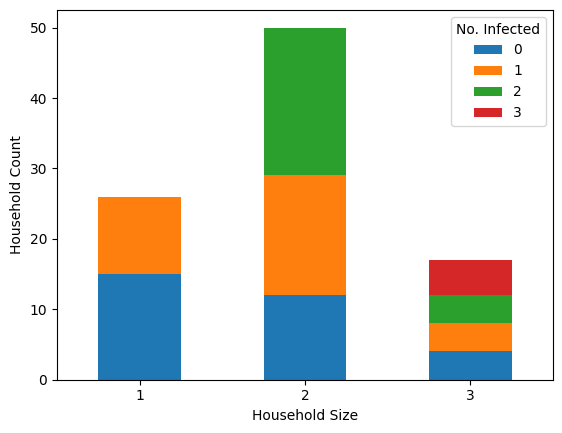

In [97]:
data.plot(x="Household Size", kind="bar", stacked=True, rot=True)
plt.legend(title="No. Infected")
plt.ylabel("Household Count")
plt.show()

## Model 1: Full Model
Two levels of Mixing

In [63]:
m1_dataset = HouseholdEpidemicModel(H, [1, 1], n_sample=N, observed_data=observed)

In [64]:
m1_dataset.sample_model()
train_data, val_data = random_split(m1_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [13]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(2, 9, 4, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/pchatha/miniforge3/envs/research/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 20.8 K | train
----

Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

/Users/pchatha/miniforge3/envs/research/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/Users/pchatha/miniforge3/envs/research/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

### Sample from Posterior

In [14]:
J = 100
x_o = m1_dataset.get_observed_data()[0]
posterior = model.sample(J, x_o)

In [28]:
torch.exp(posterior).mean(0), torch.exp(posterior).var(0)

(tensor([1.9264, 0.2368]), tensor([0.3119, 0.0516]))

In [29]:
torch.quantile(torch.exp(posterior), q=0.05, dim=0), torch.quantile(torch.exp(posterior), q=0.95, dim=0)

(tensor([1.0863, 0.0095]), tensor([2.9690, 0.6569]))

### Posterior Predictive Check

In [30]:
posterior_predictive = np.empty((J, 9))
for j in range(J):
    z = posterior[j]
    posterior_predictive[j] = m1_dataset.simulate(z, j)

In [43]:
np.array(observed)

array([0.57692308, 0.42307692, 0.24      , 0.34      , 0.42      ,
       0.23529412, 0.23529412, 0.23529412, 0.29411765])

In [42]:
posterior_predictive.mean(0)

array([0.90538462, 0.09461538, 0.8604    , 0.028     , 0.1116    ,
       0.87588235, 0.04705882, 0.02176471, 0.05529412])

# Homogeneous Model

In [46]:
m3_dataset = HouseholdEpidemicModel(H, 1., n_sample=N, observed_data=observed, model_idx=2)

In [48]:
m3_dataset.sample_model()
train_data, val_data = random_split(m3_dataset, [a, b])
train_loader = DataLoader(train_data, batch_size=200)
val_loader = DataLoader(val_data, batch_size=b)

Simulating samples...


In [62]:
m1_dataset.theta

NameError: name 'm1_dataset' is not defined

In [67]:
m3_dataset.theta = m3_dataset.theta.unsqueeze(1)

In [96]:
optim = partial(torch.optim.AdamW, lr=0.0005)
model = NeuralPosteriorEstimator(1, 9, 1, flow_type="MAF", optimizer=optim)
callbacks = [EarlyStopping(monitor="val_loss", mode="min", patience=20)]
trainer = L.Trainer(max_epochs=1000, log_every_n_steps=1, callbacks=callbacks)
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name  | Type     | Params | Mode 
-------------------------------------------
0 | embed | Identity | 0      | train
1 | flow  | MAF      | 4.9 K  | train
-------------------------------------------
4.9 K     Trainable params
0         Non-trainable params
4.9 K     Total params
0.020     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                        | 0/? [00:00<?, ?it/s]

Training: |                                                               | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

Validation: |                                                             | 0/? [00:00<?, ?it/s]

In [70]:
m3_dataset.data

tensor([[0.9615, 0.0385, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.6600,  ..., 0.1176, 0.0000, 0.2353],
        [0.2308, 0.7692, 0.0200,  ..., 0.0000, 0.0588, 0.9412],
        ...,
        [0.9615, 0.0385, 1.0000,  ..., 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.9800,  ..., 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.8800,  ..., 0.0588, 0.0000, 0.0588]])

In [76]:
m3_dataset.data[1]

tensor([1.0000, 0.0000, 0.6600, 0.1000, 0.2400, 0.6471, 0.1176, 0.0000, 0.2353])

In [94]:
# compute final size?
# a = m3_dataset.data[:, 0] + m3_dataset.data[:, 2] + m3_dataset.data[:, 5]
a = m3_dataset.data[:, 4]

In [91]:
zz = torch.exp(m3_dataset.theta)

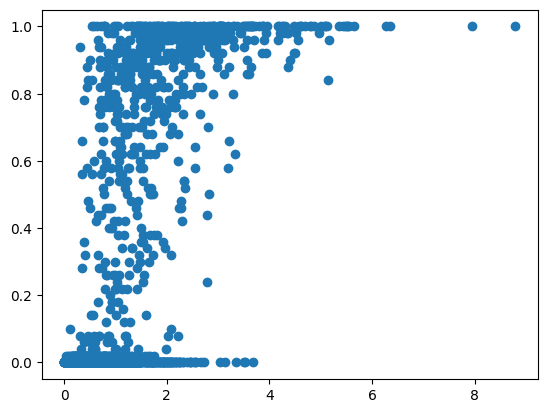

In [95]:
plt.scatter(zz, a)

In [57]:
# np.exp(-.238)

# np.exp(-1.926 * 97 / 177)

To do: try a posterior predictive check using synthetic data...